In [83]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:", project_root)
print("Current Working Directory:", os.getcwd())

Project Root: c:\Users\user\OneDrive\Desktop\resume-screening-assistant
Current Working Directory: c:\Users\user\OneDrive\Desktop\resume-screening-assistant\notebooks


In [84]:
import src

print("src imported successfully!")

src imported successfully!


In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/UpdatedResumeDataSet.csv", encoding="utf-8")

In [86]:
print("Shape:", df.shape)

print("Columns:", df.columns.tolist())

print("Missing values:")
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

Shape: (962, 2)
Columns: ['Category', 'Resume']
Missing values:
Category    0
Resume      0
dtype: int64
Duplicates: 796


In [87]:
print(df["Resume"].iloc[0][:600])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask


Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


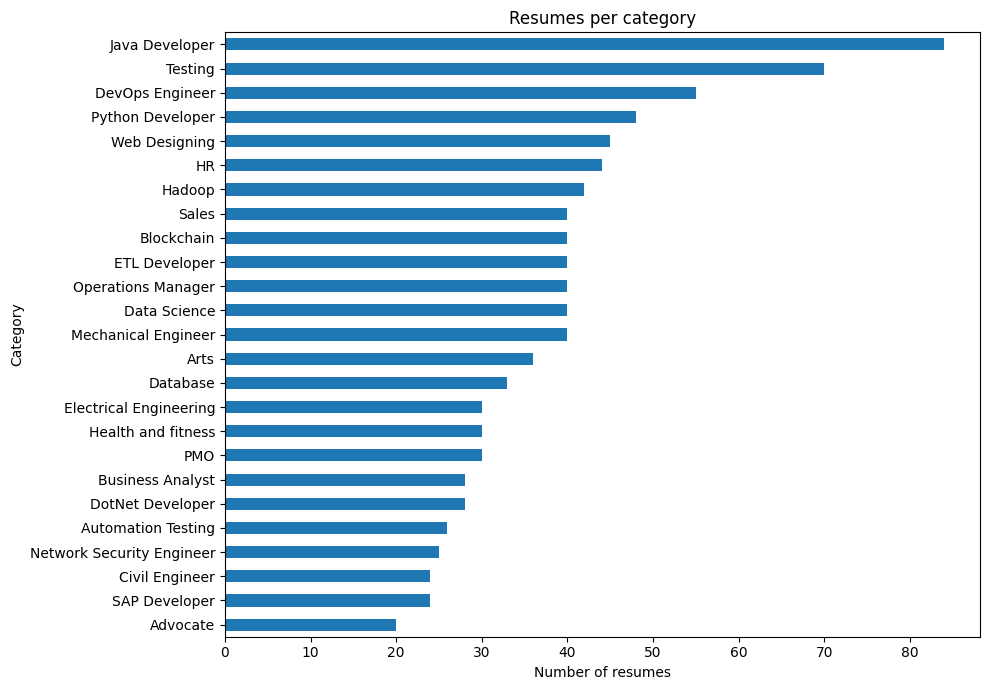

In [88]:
counts = df["Category"].value_counts()

print(counts)

plt.figure(figsize=(10,7))

counts.sort_values().plot(kind="barh")

plt.title("Resumes per category")

plt.xlabel("Number of resumes")

plt.tight_layout()

plt.savefig("../reports/class_distribution.png", dpi=150)

plt.show()

In [89]:
print("Before:", len(df))

df = df.drop_duplicates(subset=["Resume"]).reset_index(drop=True)

print("After :", len(df))

Before: 962
After : 166


In [90]:
df["n_chars"] = df["Resume"].str.len()

df["n_words"] = df["Resume"].str.split().str.len()

print(df[["n_chars", "n_words"]].describe())

            n_chars      n_words
count    166.000000   166.000000
mean    2980.114458   424.771084
std     2646.110439   380.604490
min      142.000000    19.000000
25%     1036.000000   161.250000
50%     2361.000000   330.000000
75%     3886.500000   571.500000
max    14816.000000  2209.000000


In [91]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

c:\Users\user\OneDrive\Desktop\resume-screening-assistant


In [92]:
from src.preprocess import preprocess

df["clean_resume"] = df["Resume"].apply(preprocess)

In [93]:
import os
print(os.getcwd())

c:\Users\user\OneDrive\Desktop\resume-screening-assistant\notebooks


In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

In [95]:
X = vectorizer.fit_transform(df["clean_resume"])

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (166, 5000)


In [96]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 5000
['abap' 'abb' 'ability' 'ability deal' 'ability learn' 'ability quickly'
 'ability work' 'able' 'able communicate' 'able work' 'abstract'
 'academia' 'academic' 'academy' 'academy description' 'acb' 'acb vcb'
 'accenture' 'accenture description' 'accept']


In [97]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Category"])

# Keep this — you need it later to convert predictions back to category names
print(label_encoder.classes_)

['Advocate' 'Arts' 'Automation Testing' 'Blockchain' 'Business Analyst'
 'Civil Engineer' 'Data Science' 'Database' 'DevOps Engineer'
 'DotNet Developer' 'ETL Developer' 'Electrical Engineering' 'HR' 'Hadoop'
 'Health and fitness' 'Java Developer' 'Mechanical Engineer'
 'Network Security Engineer' 'Operations Manager' 'PMO' 'Python Developer'
 'SAP Developer' 'Sales' 'Testing' 'Web Designing']


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_resume"],   # Still text, not TF-IDF vectors
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [99]:
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 132
Testing samples : 34


In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [3000, 5000, 8000],
    "clf__C": [0.1, 1.0, 10.0],
}

grid = GridSearchCV(
    build_pipeline(
        LogisticRegression(
            max_iter=1000,
            random_state=42,
        )
    ),
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Macro-F1:", round(grid.best_score_, 4))

best_model = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\user\OneDrive\Desktop\resume-screening-assistant\venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'clf__C': 10.0, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Best Macro-F1: 0.7764


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

def build_pipeline(classifier):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                sublinear_tf=True,
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.9,
            ),
        ),
        ("clf", classifier),
    ])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

def build_pipeline(classifier):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                sublinear_tf=True,
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.9,
            ),
        ),
        ("clf", classifier),
    ])

In [102]:
print(type(X_train))
print(type(y_train))
print(type(label_encoder))
print(type(cv))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
<class 'sklearn.model_selection._split.StratifiedKFold'>


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
print(type(X_train))
print(type(y_train))
print(type(label_encoder))
print(type(cv))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
<class 'sklearn.model_selection._split.StratifiedKFold'>


In [104]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Macro-F1 :", round(f1_score(y_test, y_pred, average="macro"), 4))
print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
    )
)

Accuracy : 0.8824
Macro-F1 : 0.821

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       0.50      1.00      0.67         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       1.00      1.00      1.00         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
                   Hadoop

c:\Users\user\OneDrive\Desktop\resume-screening-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\OneDrive\Desktop\resume-screening-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\OneDrive\Desktop\resume-screening-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

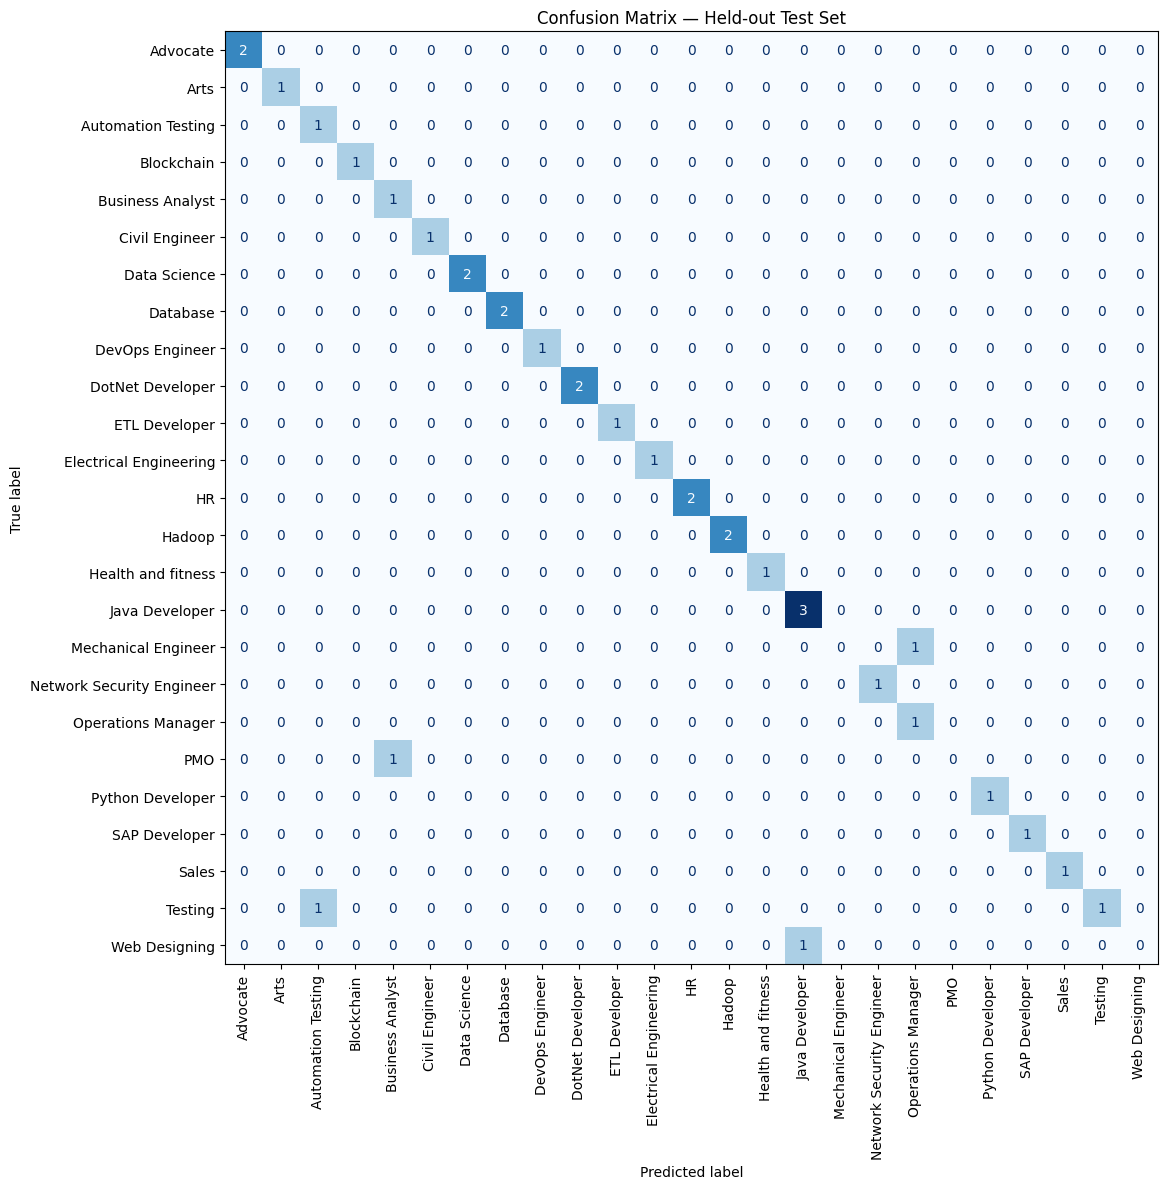

In [105]:
fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

plt.title("Confusion Matrix — Held-out Test Set")
plt.tight_layout()

plt.savefig("../reports/confusion_matrix.png", dpi=150)

plt.show()

In [106]:
import pandas as pd

errors = pd.DataFrame({
    "true": label_encoder.inverse_transform(y_test),
    "pred": label_encoder.inverse_transform(y_pred),
    "text": X_test.values,
})

errors = errors[errors["true"] != errors["pred"]]

print(f"{len(errors)} misclassified out of {len(y_test)}")

print(
    errors.groupby(["true", "pred"])
          .size()
          .sort_values(ascending=False)
          .head(10)
)

4 misclassified out of 34
true                 pred              
Mechanical Engineer  Operations Manager    1
PMO                  Business Analyst      1
Testing              Automation Testing    1
Web Designing        Java Developer        1
dtype: int64


In [108]:
import numpy as np

tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())

for idx, category in enumerate(label_encoder.classes_[:5]):
    top = np.argsort(clf.coef_[idx])[-8:][::-1]
    print(f"{category:24s} -> {', '.join(feature_names[top])}")

Advocate                 -> advocate, law, legal, court, llb, advocate skill, maharashtra board, high court
Arts                     -> art, total, art commerce, commerce science, state, searching, gold, programme
Automation Testing       -> automation, automation testing, selenium, testing, tester, manual, manual automation, test case
Blockchain               -> blockchain, smart, blockchain developer, smart contract, ethereum, contract, virtual, school blockchain
Business Analyst         -> business analyst, analyst, functional, business, functional requirement, analyst business, gathering, specification


In [109]:
print(type(best_model))

<class 'sklearn.pipeline.Pipeline'>


In [110]:
import joblib
from pathlib import Path
from sklearn import __version__ as sklearn_version
from sklearn.metrics import f1_score

# Create the models folder if it doesn't exist
Path("../models").mkdir(exist_ok=True)

artifact = {
    "pipeline": best_model,          # TF-IDF + classifier together
    "label_encoder": label_encoder,  # Maps numbers back to category names
    "macro_f1": float(
        f1_score(y_test, y_pred, average="macro")
    ),
    "sklearn_version": sklearn_version,
}

joblib.dump(
    artifact,
    "../models/resume_classifier.joblib"
)

print("Saved successfully!")

Saved successfully!
